In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


In [3]:
# Load the dataset using the precise path
df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')

# View the first few rows to make sure it loaded correctly
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 2. Explore the data structure and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 3. Data Cleaning and Feature Engineering

# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert 'Sex' to numbers: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Select the main features we want to use for training
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# Check our cleaned features
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [6]:
# 3. Data Cleaning and Feature Engineering

# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Convert 'Sex' to numbers: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Select the main features we want to use for training
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# Check our cleaned features
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,NaN,22.0,1,0,7.2500
1,1,NaN,38.0,1,0,71.2833
2,3,NaN,26.0,0,0,7.9250
3,1,NaN,35.0,1,0,53.1000
4,3,NaN,35.0,0,0,8.0500


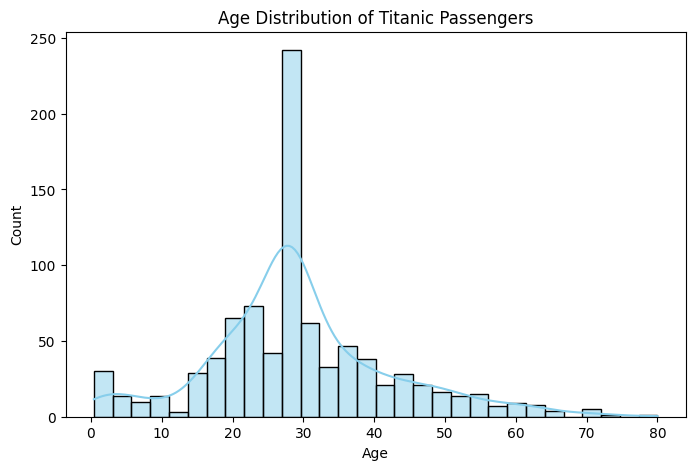

Success! Cleaned dataset saved to: /kaggle/working/cleaned_titanic_dataset.csv


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean remaining missing data (Embarked has 2 missing values)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Encode 'Embarked' column (C -> 0, Q -> 1, S -> 2)
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 3. Visualize age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 4. Output cleaned dataset as a new CSV
output_path = '/kaggle/working/cleaned_titanic_dataset.csv'
df.to_csv(output_path, index=False)

print(f"Success! Cleaned dataset saved to: {output_path}")

In [8]:
# 1. Reload a fresh copy to fix the Sex column overwrite
final_df = pd.read_csv('/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv')

# 2. Clean missing data
final_df['Age'] = final_df['Age'].fillna(final_df['Age'].median())
final_df['Embarked'] = final_df['Embarked'].fillna(final_df['Embarked'].mode()[0])

# 3. Encode Categorical Columns
final_df['Sex'] = final_df['Sex'].map({'male': 0, 'female': 1})
final_df['Embarked'] = final_df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 4. Save the final perfectly cleaned dataset
final_output = '/kaggle/working/cleaned_titanic_dataset.csv'
final_df.to_csv(final_output, index=False)

# 5. Verify there are no missing values left (except Cabin if you chose to leave it)
print("--- Missing Values Check ---")
print(final_df[['Sex', 'Age', 'Embarked']].isnull().sum())
print(f"\nPerfect! Final dataset successfully overwritten at: {final_output}")

--- Missing Values Check ---
Sex         0
Age         0
Embarked    0
dtype: int64

Perfect! Final dataset successfully overwritten at: /kaggle/working/cleaned_titanic_dataset.csv
